# Making the dataset and training the model

This file contains the code to make the dataset from depth tensor and the embeddings retrieved from the same tensors. But also one thing to keep track is 
error value of -1 for places where no depth values could be retriebed. They need to be filtered out and left out of the final training data. 

In [24]:
import argparse
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

In [18]:
class EmbedDepthDataset(Dataset):
    """
    This class matched the YOLO embeddings from a file to depth retrieved
    for the same images and creates a dataset from them, that can be used to 
    train the final model.

    Args:
        embed_path: path to .pt embeddings (N,256)
        depths_path: path to .pt (N,)
    """

    def __init__(self, embed_path: str, depths_path: str):
        #opening the files
        embeds = torch.load(embed_path, weights_only=True).float()
        depths = torch.load(depths_path, weights_only=True).float()

        #filtering depths to only allow valid ones
        print(f"Removing {(depths==-1).sum()} invalid depths")
        mask = depths != -1
        embeds_masked = embeds[mask]
        depths_masked = depths[mask]   

        #saving results
        self.depths = depths_masked
        self.embeddings = embeds_masked

        assert len(self.embeddings)==len(self.depths), (
            f"The embeddings array is not the same length as the depths"
            f"EMBEDDINGS: {len(self.embeddings)}\nDEPTHS: {len(self.depths)}"
        )

    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.depths[idx]

In [ ]:
class DistanceRegressor(nn.Module):
    """
    Model to predict based on YOLO embeddings the distance to a car. It takes in (256) embedding and 
    outputs a single distance value in meters.

    Architecture is similar to the paper:
    1. Linear(256,128) + ReLU
    2. Linear(128,64) + ReLU
    3. Linear(64,1) + Softplus (to ensure positive output)
    """

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(256, 128),
            nn.Linear(128, 64),
            nn.Linear(64, 1),
            nn.Softplus()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [20]:
EMBED_PATH = "../data/embeds_preds.pt"
DEPTHS_PATH = "../data/ransac_depth.pt"

dataset = EmbedDepthDataset(EMBED_PATH, DEPTHS_PATH)

Removing 4 invalid depths


In [21]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.Adam(DistanceRegressor().parameters(), lr=0.001, eps=1.0)

epochs = 1000

In [22]:
losses = np.array([])

for epoch in range(epochs):
    for embeds, depths in DataLoader(dataset, batch_size=32, shuffle=True):
        # Forward pass
        preds = DistanceRegressor()(embeds)
        loss = loss_fn(preds.squeeze(), depths)
        losses = np.append(losses, loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/1000, Loss: 9.1273
Epoch 101/1000, Loss: 21.7073
Epoch 201/1000, Loss: 18.6108
Epoch 301/1000, Loss: 15.7227
Epoch 401/1000, Loss: 13.6058
Epoch 501/1000, Loss: 9.9407
Epoch 601/1000, Loss: 7.5859
Epoch 701/1000, Loss: 13.9675
Epoch 801/1000, Loss: 9.1570
Epoch 901/1000, Loss: 17.3192


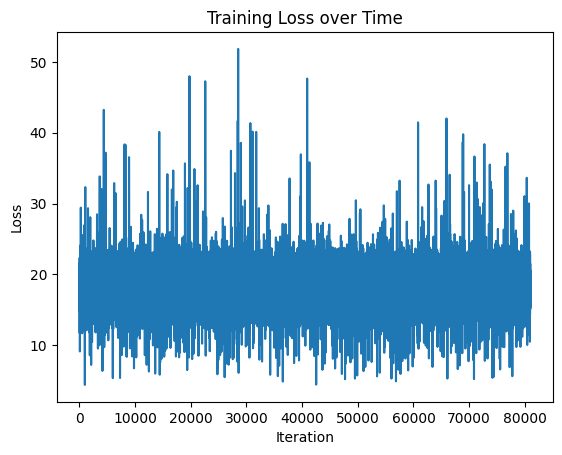

In [25]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.show()